# Vulgar Nickname Detection — Model Comparison

Comparison of 5 approaches for vulgar nickname classification:

| # | Approach | Type |
|---|---|---|
| 1 | Word-list substring match | rule-based |
| 2 | Hamming distance (sliding window) | rule-based |
| 3 | Char n-gram + Logistic Regression | classic ML |
| 4 | Char n-gram + 2-layer MLP | NN |
| 5 | Char-CNN | NN |

All models are trained by `python -m nick_moderator.train` and saved to `artifacts/`.
This notebook only **loads** them and evaluates on the held-out test set.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report,
)

from nick_moderator.config import ARTIFACTS_DIR
from nick_moderator.inference import NickModerator

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load test set + dataset info

In [2]:
test_df = pd.read_parquet(ARTIFACTS_DIR / "test.parquet")
info = json.loads((ARTIFACTS_DIR / "dataset_info.json").read_text())

print(f"Test set size: {len(test_df):,}")
print(f"Vulgar fraction: {test_df['label'].mean()*100:.1f}%")
print(f"\nBy source:")
print(test_df["source"].value_counts().to_string())
print(f"\nDataset metadata:")
print(json.dumps(info, indent=2))

Test set size: 49,805
Vulgar fraction: 43.7%

By source:
source
namespotting_clean    20095
namespotting_toxic    12176
pl_augmented           9580
pl_synthetic_clean     7954

Dataset metadata:
{
  "total": 498053,
  "train": 398443,
  "val": 49805,
  "test": 49805,
  "vulgar_pct": 0.43781485102991047,
  "by_source": {
    "namespotting_clean": 200000,
    "namespotting_toxic": 122158,
    "pl_augmented": 95897,
    "pl_synthetic_clean": 79998
  },
  "banlist_size": 11403
}


## 2. Load all models from `artifacts/`

In [3]:
moderator = NickModerator(artifacts_dir=ARTIFACTS_DIR, device="cpu")
print("Loaded models from disk:")
for name in ["wordlist", "hamming", "logreg", "mlp", "cnn"]:
    print(f"  - {name}")

Loaded models from disk:
  - wordlist
  - hamming
  - logreg
  - mlp
  - cnn


## 3. Run all models on the test set + measure latency

In [4]:
EVAL_SAMPLE = 5000  # full test set has 49k nicks; Hamming is O(n*banlist) so we sample
test_eval = test_df.sample(n=min(EVAL_SAMPLE, len(test_df)), random_state=42).reset_index(drop=True)
nicks_test = test_eval["nick"].tolist()
y_test = test_eval["label"].to_numpy()
print(f"Evaluating on {len(test_eval):,} sampled nicks (vulgar fraction: {y_test.mean()*100:.1f}%)")

predictions = {}
probabilities = {}
latencies_ms = {}

for model_name in ["wordlist", "hamming", "logreg", "mlp", "cnn"]:
    t0 = time.time()
    if model_name == "wordlist":
        proba = moderator.wordlist.predict(nicks_test).astype(np.float32)
    elif model_name == "hamming":
        proba = moderator.hamming.predict(nicks_test).astype(np.float32)
    elif model_name == "logreg":
        proba = moderator.logreg.predict_proba(nicks_test)
    elif model_name == "mlp":
        proba = moderator.predict_mlp_proba(nicks_test)
    elif model_name == "cnn":
        proba = moderator.predict_cnn_proba(nicks_test)
    dt = time.time() - t0
    latencies_ms[model_name] = dt / len(nicks_test) * 1000
    probabilities[model_name] = proba
    predictions[model_name] = (proba >= 0.5).astype(np.int8)
    print(f"  {model_name:>10s}: {dt:.2f}s for {len(nicks_test):,} nicks  ({latencies_ms[model_name]:.3f} ms/nick)")


Evaluating on 5,000 sampled nicks (vulgar fraction: 44.3%)


    wordlist: 1.87s for 5,000 nicks  (0.374 ms/nick)


     hamming: 255.26s for 5,000 nicks  (51.052 ms/nick)


      logreg: 0.27s for 5,000 nicks  (0.053 ms/nick)


         mlp: 1.70s for 5,000 nicks  (0.339 ms/nick)


         cnn: 0.34s for 5,000 nicks  (0.067 ms/nick)


## 4. Metrics comparison

In [5]:
rows = []
for name, pred in predictions.items():
    proba = probabilities[name]
    # AUC only meaningful when model produces probabilities (rule-based: just 0/1)
    try:
        auc = roc_auc_score(y_test, proba)
    except ValueError:
        auc = float("nan")
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": auc,
        "ms_per_nick": latencies_ms[name],
    })

results = pd.DataFrame(rows).set_index("model")
display_results = results.copy()
for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    display_results[col] = display_results[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
display_results["ms_per_nick"] = display_results["ms_per_nick"].apply(lambda x: f"{x:.3f}")
print(display_results.to_string())

         accuracy precision  recall      f1 roc_auc ms_per_nick
model                                                          
wordlist   0.6902    0.9883  0.3046  0.4657  0.6509       0.374
hamming    0.6592    0.6700  0.4553  0.5422  0.6384      51.052
logreg     0.9452    0.9533  0.9215  0.9371  0.9861       0.053
mlp        0.9608    0.9587  0.9526  0.9556  0.9934       0.339
cnn        0.9492    0.9588  0.9251  0.9417  0.9877       0.067


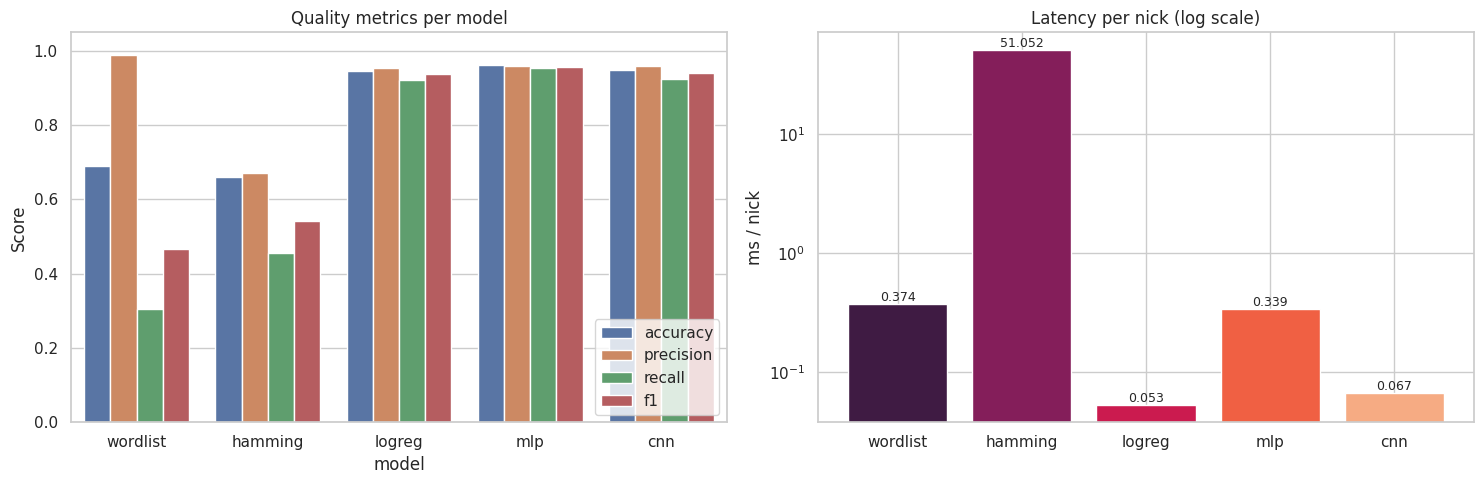

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
plot_df = results[metrics_to_plot].reset_index().melt(id_vars="model", var_name="metric")
sns.barplot(data=plot_df, x="model", y="value", hue="metric", ax=axes[0])
axes[0].set_title("Quality metrics per model")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")

ax = axes[1]
ax.bar(results.index, results["ms_per_nick"], color=sns.color_palette("rocket", len(results)))
ax.set_yscale("log")
ax.set_title("Latency per nick (log scale)")
ax.set_ylabel("ms / nick")
for i, v in enumerate(results["ms_per_nick"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Confusion matrices

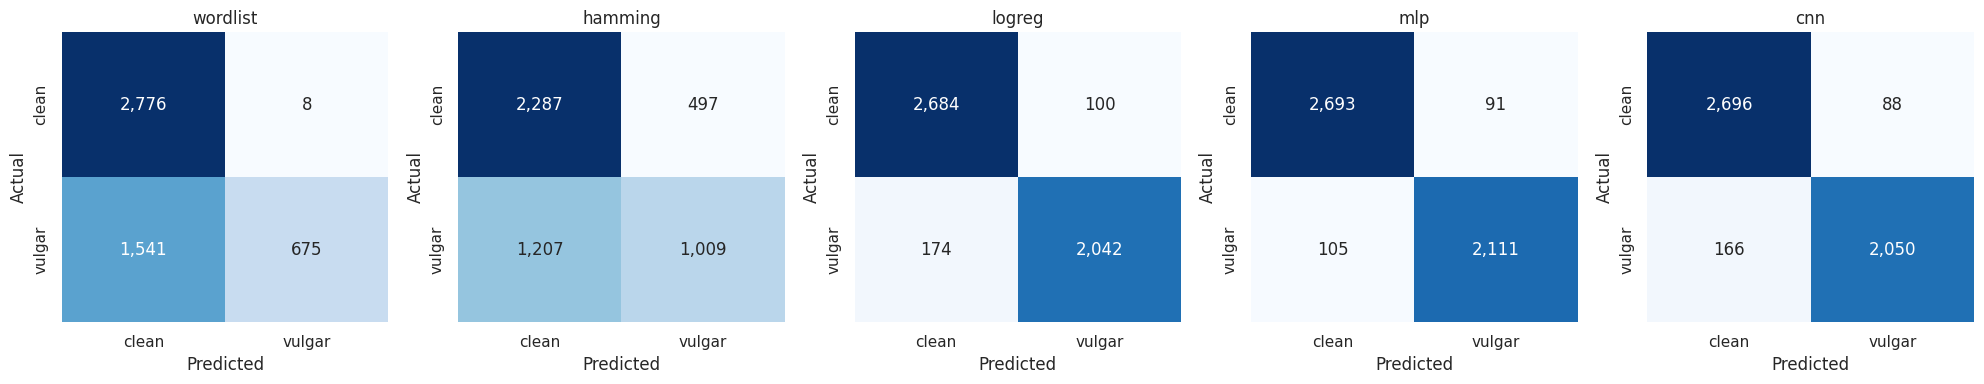

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["clean", "vulgar"], yticklabels=["clean", "vulgar"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 6. Performance broken down by data source

The test set is a mix of EN Reddit (Namespotting) and synthetic PL nicks.
Each model may behave very differently on these subsets.

In [8]:
by_source_rows = []
for src in test_eval["source"].unique():
    mask = test_eval["source"].values == src
    y_src = y_test[mask]
    if y_src.sum() == 0 or y_src.sum() == len(y_src):
        # one-class slice — only accuracy is meaningful
        for name, pred in predictions.items():
            by_source_rows.append({
                "source": src, "model": name, "n": int(mask.sum()),
                "accuracy": accuracy_score(y_src, pred[mask]),
                "f1": float("nan"),
            })
        continue
    for name, pred in predictions.items():
        by_source_rows.append({
            "source": src, "model": name, "n": int(mask.sum()),
            "accuracy": accuracy_score(y_src, pred[mask]),
            "f1": f1_score(y_src, pred[mask], zero_division=0),
        })

by_source = pd.DataFrame(by_source_rows)
print(by_source.pivot_table(index="model", columns="source", values="accuracy").round(4).to_string())
print()
print("F1 by source:")
print(by_source.pivot_table(index="model", columns="source", values="f1").round(4).to_string())


source    namespotting_clean  namespotting_toxic  pl_augmented  pl_synthetic_clean
model                                                                             
cnn                   0.9555              0.8749        0.9860               1.000
hamming               0.8559              0.2848        0.6623               0.737
logreg                0.9494              0.8749        0.9780               1.000
mlp                   0.9540              0.9276        0.9830               1.000
wordlist              0.9960              0.0667        0.5934               1.000

F1 by source:
Empty DataFrame
Columns: []
Index: []


## 7. Smoke test on hand-crafted PL examples

These are NOT from the training/test set — purely held-out hand-crafted to test
how models react to obfuscated Polish vulgar nicks vs clean nicks.

In [9]:
examples = [
    # Vulgar PL (expected = 1)
    ("kurwa_master", 1),
    ("xXkurw4Xx", 1),
    ("k_u_r_w_a", 1),
    ("kurwiszcze69", 1),
    ("pierd0lec", 1),
    ("ch00j_pl", 1),
    ("jebany_smok", 1),
    ("d0p1erd0l1c", 1),
    # Clean (expected = 0)
    ("marek_92", 0),
    ("dragon_slayer", 0),
    ("anna.kowalska", 0),
    ("xPro_Gamer", 0),
    ("hubert_2003", 0),
    ("the_warrior", 0),
    ("monika.nowak", 0),
    ("smok_legendarny", 0),
]
example_nicks = [e[0] for e in examples]
example_labels = np.array([e[1] for e in examples])

example_proba = moderator.predict_all_proba(example_nicks)
example_df = pd.DataFrame({"nick": example_nicks, "expected": example_labels})
for name, proba in example_proba.items():
    example_df[name] = [f"{p:.3f}" for p in proba]

print(example_df.to_string(index=False))

           nick  expected wordlist hamming logreg   mlp   cnn
   kurwa_master         1    1.000   1.000  0.955 0.996 0.999
      xXkurw4Xx         1    1.000   1.000  0.946 0.993 0.999
      k_u_r_w_a         1    0.000   0.000  0.860 0.993 0.998
   kurwiszcze69         1    1.000   1.000  0.999 1.000 1.000
      pierd0lec         1    0.000   1.000  0.956 0.999 0.993
       ch00j_pl         1    0.000   0.000  0.910 0.996 0.354
    jebany_smok         1    1.000   1.000  0.994 1.000 1.000
    d0p1erd0l1c         1    0.000   0.000  0.882 1.000 0.994
       marek_92         0    0.000   0.000  0.000 0.000 0.000
  dragon_slayer         0    0.000   0.000  0.221 0.005 0.009
  anna.kowalska         0    0.000   0.000  0.023 0.003 0.050
     xPro_Gamer         0    0.000   0.000  0.268 0.004 0.011
    hubert_2003         0    0.000   1.000  0.015 0.000 0.001
    the_warrior         0    0.000   0.000  0.304 0.008 0.012
   monika.nowak         0    0.000   0.000  0.016 0.073 0.000
smok_leg

## 8. Final ranking + recommendation

In [10]:
ranking = results.sort_values("f1", ascending=False).copy()
print("Models ranked by F1:")
print(ranking[["accuracy", "precision", "recall", "f1", "roc_auc", "ms_per_nick"]].to_string())

best = ranking.index[0]
print(f"\nBest by F1: {best}")
print(f"  F1={ranking.loc[best, 'f1']:.4f}, latency={ranking.loc[best, 'ms_per_nick']:.3f} ms/nick")

Models ranked by F1:
          accuracy  precision    recall        f1   roc_auc  ms_per_nick
model                                                                   
mlp         0.9608   0.958674  0.952617  0.955636  0.993369     0.339253
cnn         0.9492   0.958840  0.925090  0.941663  0.987706     0.067130
logreg      0.9452   0.953315  0.921480  0.937127  0.986119     0.053432
hamming     0.6592   0.669987  0.455325  0.542182  0.638402    51.051830
wordlist    0.6902   0.988287  0.304603  0.465678  0.650865     0.373837

Best by F1: mlp
  F1=0.9556, latency=0.339 ms/nick


## 9. Test your own nick

Run this cell with any nickname — get predictions from all 5 models side-by-side.

In [11]:
def test_nick(nick: str, threshold: float = 0.5) -> None:
    """Run all 5 models on a single nick and print a verdict table."""
    proba = moderator.predict_all_proba([nick])
    print(f"\nNick: {nick!r}")
    print(f"{'-' * 50}")
    print(f"{'Model':<12} {'Score':>8}  Verdict")
    print(f"{'-' * 50}")
    flags = []
    for name in ["wordlist", "hamming", "logreg", "mlp", "cnn"]:
        score = float(proba[name][0])
        is_vulgar = score >= threshold
        flags.append(is_vulgar)
        verdict = "VULGAR" if is_vulgar else "clean"
        print(f"{name:<12} {score:>8.3f}  {verdict}")
    print(f"{'-' * 50}")
    n_vulgar = sum(flags)
    if n_vulgar >= 3:
        print(f"=> CONSENSUS: VULGAR  ({n_vulgar}/5 models flag it)")
    elif n_vulgar == 0:
        print(f"=> CONSENSUS: CLEAN  (0/5 models flag it)")
    else:
        print(f"=> CONSENSUS: AMBIGUOUS  ({n_vulgar}/5 models flag it)")


def test_nicks(nicks: list[str], threshold: float = 0.5) -> pd.DataFrame:
    """Batch version — returns a DataFrame with scores per model."""
    proba = moderator.predict_all_proba(nicks)
    df = pd.DataFrame({"nick": nicks})
    for name in ["wordlist", "hamming", "logreg", "mlp", "cnn"]:
        df[name] = [f"{p:.3f}" for p in proba[name]]
        df[f"{name}_vulgar"] = (proba[name] >= threshold).astype(int)
    df["consensus"] = df[[f"{n}_vulgar" for n in ["wordlist", "hamming", "logreg", "mlp", "cnn"]]].sum(axis=1)
    df["verdict"] = df["consensus"].apply(lambda c: "VULGAR" if c >= 3 else ("clean" if c == 0 else "ambiguous"))
    return df


# ── Try it: edit the list and re-run ──────────────────────────────────────
my_nicks = [
    "kurwiszcze420",
    "marek_kowalski",
    "xX_pierd0lec_Xx",
    "anna2003",
]

for nick in my_nicks:
    test_nick(nick)


Nick: 'kurwiszcze420'
--------------------------------------------------
Model           Score  Verdict
--------------------------------------------------
wordlist        1.000  VULGAR
hamming         1.000  VULGAR
logreg          0.999  VULGAR
mlp             1.000  VULGAR
cnn             1.000  VULGAR
--------------------------------------------------
=> CONSENSUS: VULGAR  (5/5 models flag it)



Nick: 'marek_kowalski'
--------------------------------------------------
Model           Score  Verdict
--------------------------------------------------
wordlist        0.000  clean
hamming         0.000  clean
logreg          0.003  clean
mlp             0.000  clean
cnn             0.002  clean
--------------------------------------------------
=> CONSENSUS: CLEAN  (0/5 models flag it)



Nick: 'xX_pierd0lec_Xx'
--------------------------------------------------
Model           Score  Verdict
--------------------------------------------------
wordlist        0.000  clean
hamming         1.000  VULGAR
logreg          0.952  VULGAR
mlp             0.999  VULGAR
cnn             0.999  VULGAR
--------------------------------------------------
=> CONSENSUS: VULGAR  (4/5 models flag it)

Nick: 'anna2003'
--------------------------------------------------
Model           Score  Verdict
--------------------------------------------------
wordlist        0.000  clean
hamming         0.000  clean
logreg          0.015  clean
mlp             0.001  clean
cnn             0.001  clean
--------------------------------------------------
=> CONSENSUS: CLEAN  (0/5 models flag it)


## 10. Custom held-out test set

`tests/custom_test_set.json` is a hand-crafted set of nicks **not seen during training**.
It covers: simple PL vulgar, leet, separators, affixes, EN vulgar, clean PL/EN, and
edge-cases ("scunthorpe", "analog", PL surnames containing substrings of vulgar words).

In [12]:
custom_path = Path("tests/custom_test_set.json")
custom = json.loads(custom_path.read_text(encoding="utf-8"))
custom_df = pd.DataFrame(custom["samples"])

print(f"Custom test set: {len(custom_df)} samples")
print(f"Vulgar: {(custom_df['label'] == 1).sum()}, Clean: {(custom_df['label'] == 0).sum()}")
print(f"\nBy category:")
print(custom_df.groupby(["category", "label"]).size().to_string())

Custom test set: 69 samples
Vulgar: 29, Clean: 40

By category:
category             label
clean_minimal        0         8
edge_false_positive  0        10
en_clean_gamer       0         7
en_vulgar            1         4
en_vulgar_leet       1         1
pl_clean_gamer       0         7
pl_clean_name        0         8
pl_vulgar_affix      1         4
pl_vulgar_leet       1         7
pl_vulgar_separator  1         5
pl_vulgar_simple     1         8


In [13]:
custom_nicks = custom_df["nick"].tolist()
custom_y = custom_df["label"].to_numpy()
custom_proba = moderator.predict_all_proba(custom_nicks)

# Per-model metrics
custom_rows = []
for name, proba in custom_proba.items():
    pred = (proba >= 0.5).astype(np.int8)
    custom_rows.append({
        "model": name,
        "accuracy": accuracy_score(custom_y, pred),
        "precision": precision_score(custom_y, pred, zero_division=0),
        "recall": recall_score(custom_y, pred, zero_division=0),
        "f1": f1_score(custom_y, pred, zero_division=0),
    })
custom_results = pd.DataFrame(custom_rows).set_index("model")
print("Performance on custom held-out set:")
print(custom_results.round(4).to_string())

Performance on custom held-out set:
          accuracy  precision  recall      f1
model                                        
wordlist    0.7826     1.0000  0.4828  0.6512
hamming     0.7101     0.7143  0.5172  0.6000
logreg      0.8551     0.7879  0.8966  0.8387
mlp         0.8986     0.8438  0.9310  0.8852
cnn         0.8986     0.8929  0.8621  0.8772


In [14]:
# Per-category breakdown — which obfuscation types each model handles
cat_rows = []
for cat in custom_df["category"].unique():
    mask = custom_df["category"].values == cat
    y = custom_y[mask]
    n = mask.sum()
    expected = "vulgar" if y[0] == 1 else "clean"
    row = {"category": cat, "n": n, "expected": expected}
    for name in ["wordlist", "hamming", "logreg", "mlp", "cnn"]:
        pred = (custom_proba[name][mask] >= 0.5).astype(np.int8)
        row[name] = f"{(pred == y).mean()*100:.0f}%"
    cat_rows.append(row)
cat_df = pd.DataFrame(cat_rows).set_index("category")
print("Per-category accuracy (% correctly classified):")
print(cat_df.to_string())

Per-category accuracy (% correctly classified):
                      n expected wordlist hamming logreg   mlp   cnn
category                                                            
pl_vulgar_simple      8   vulgar     100%    100%   100%  100%   75%
pl_vulgar_leet        7   vulgar      14%     29%    71%   71%   86%
edge_false_positive  10    clean     100%     60%    50%   70%   80%
pl_vulgar_separator   5   vulgar       0%      0%    80%  100%   80%
pl_vulgar_affix       4   vulgar     100%    100%   100%  100%  100%
en_vulgar             4   vulgar      25%     25%   100%  100%  100%
en_vulgar_leet        1   vulgar       0%      0%   100%  100%  100%
pl_clean_name         8    clean     100%     75%   100%  100%  100%
pl_clean_gamer        7    clean     100%    100%    71%   71%   86%
en_clean_gamer        7    clean     100%    100%   100%  100%  100%
clean_minimal         8    clean     100%    100%   100%  100%  100%


In [15]:
# Show all errors per model — useful for spotting failure modes
print("=== Mistakes per model on custom test set ===\n")
for name in ["wordlist", "hamming", "logreg", "mlp", "cnn"]:
    pred = (custom_proba[name] >= 0.5).astype(np.int8)
    mistakes = custom_df[pred != custom_y].copy()
    mistakes["score"] = custom_proba[name][pred != custom_y].round(3)
    mistakes["predicted"] = pred[pred != custom_y]
    print(f"\n{name}: {len(mistakes)} mistakes / {len(custom_df)}")
    if len(mistakes) > 0:
        print(mistakes[["nick", "label", "predicted", "score", "category"]].to_string(index=False))

=== Mistakes per model on custom test set ===


wordlist: 15 mistakes / 69
             nick  label  predicted  score            category
            kvrwa      1          0    0.0      pl_vulgar_leet
        p13rd0l3c      1          0    0.0      pl_vulgar_leet
     ch00j_master      1          0    0.0      pl_vulgar_leet
        j3b@ny_xd      1          0    0.0      pl_vulgar_leet
        c1p4_lord      1          0    0.0      pl_vulgar_leet
      d0p13rd0l1c      1          0    0.0      pl_vulgar_leet
        k_u_r_w_a      1          0    0.0 pl_vulgar_separator
        k.u.r.w.a      1          0    0.0 pl_vulgar_separator
          ku-rw-a      1          0    0.0 pl_vulgar_separator
p.i.e.r.d.o.l.e.c      1          0    0.0 pl_vulgar_separator
           ch_u_j      1          0    0.0 pl_vulgar_separator
        n1gger_xd      1          0    0.0      en_vulgar_leet
       asshole420      1          0    0.0           en_vulgar
      shitlord_69      1          0    0.0 